# Explored

- Dataload/Transform

- Split/bootstrap data

- principle component analysis

- clustering as prediction

# Not done yet....

Train resnet?

more models?

In [107]:

import torch


torch.cuda.is_available()

True

Obligitory dataloaders.  see other notebook for working out for these, but load data/transform normalize spectograms

Dataset is a number of different drone signals

- https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification-v2/data


In [108]:
from collections import defaultdict

from torchaudio.transforms import Spectrogram
from torch.utils.data import Dataset
import os
import matplotlib.pyplot as plt

device = torch.device("cuda")

class SpectrogramTransform:
    def __init__(self):
        self.spectrogram_transform = Spectrogram()

    def __call__(self, iq_data):
        spectrogram = self.spectrogram_transform(iq_data['x_iq'])

        # normalize the spectrogram
        spectrogram = (spectrogram - spectrogram.mean()) / spectrogram.std()
        
        return spectrogram



class DroneRFDataSet(Dataset):
    def __init__(self, data_path, Transform, samplesize=None, device=None, seed=42):
        self.data_path = data_path
        self.transform = Transform
        self.device = device if device is not None else torch.device("cuda")
        self.rng = random.Random(seed)

        all_files = sorted(
            [f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")]
        )

        if samplesize is not None:
            by_target = defaultdict(list)
            for f in all_files:
                target = int(f.split("_")[2][6:])
                by_target[target].append(f)

            n_classes = len(by_target)

            n_per_class = max(1, samplesize // n_classes)
            selected = []

            for target in sorted(by_target):
                files = by_target[target][:]
                self.rng.shuffle(files)
                selected.extend(files[:min(n_per_class, len(files))])

            self.rng.shuffle(selected)
            if len(selected) > samplesize:
                selected = selected[:samplesize]

            self.files = selected
        else:
            self.files = all_files

        self.samples = []
        self.targets = []
        self.snrs = []

        for file in self.files:
            sample_id = file.split("_")[1][6:]
            target = int(file.split("_")[2][6:])
            # snr = file.split(".")[0].split("-")[-1]

            self.samples.append(sample_id)
            self.targets.append(target)
            # self.snrs.append(snr)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file = self.files[index]
        sample_id = self.samples[index]
        target = int(self.targets[index])

        data = torch.load(os.path.join(self.data_path, file))
        data = self.transform(data)

        return sample_id, target, data

def showspectrogram(data):
    plt.figure(figsize=(10, 4))
    plt.imshow(data.log2()[0,:,:].detach().cpu(), aspect='auto', origin='lower')
    plt.title("Spectrogram")
    plt.xlabel("Time")
    plt.show()


visualise spectograms

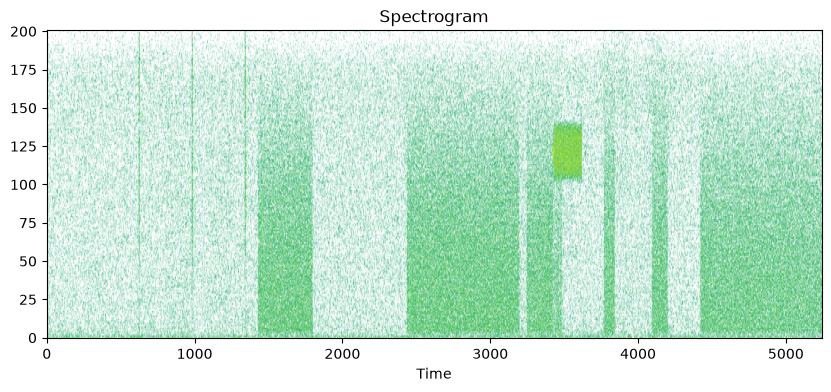

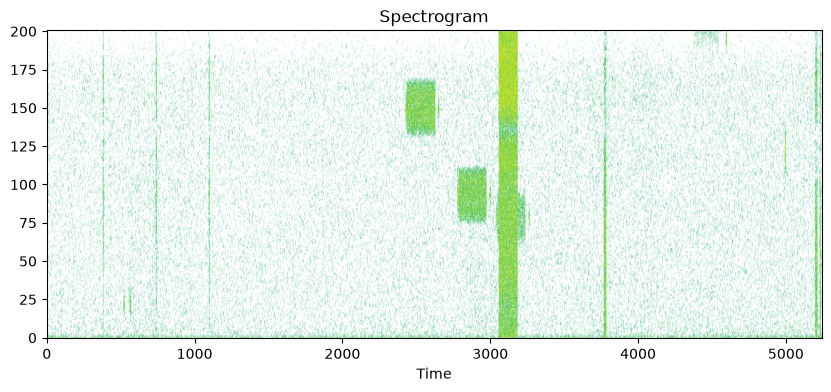

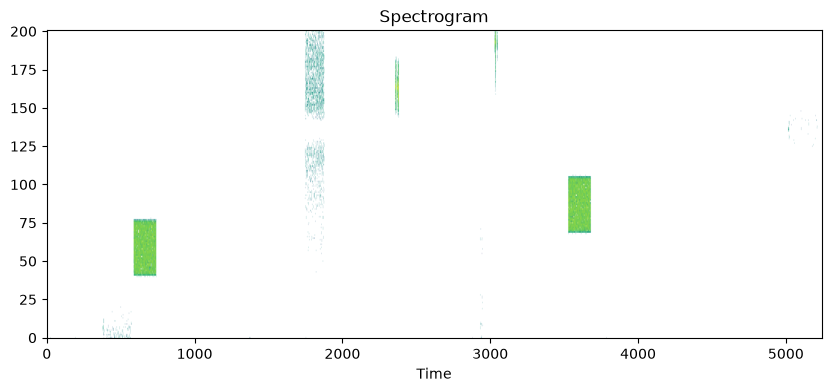

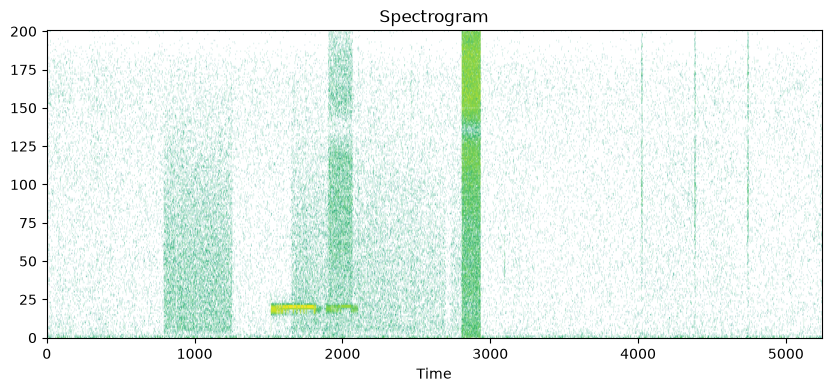

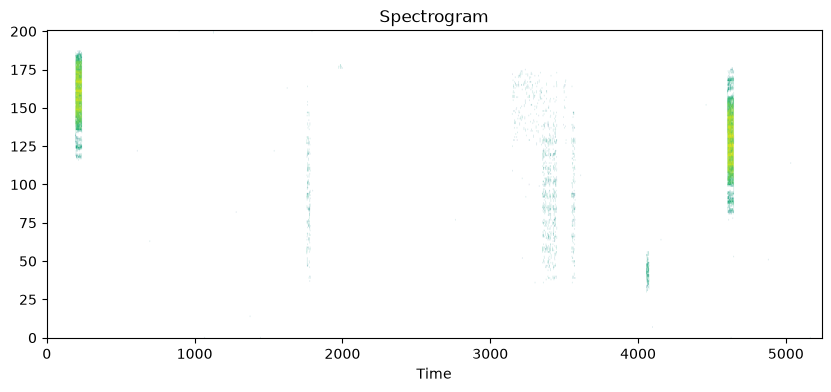

In [109]:
import random

data_path = "../data"

for i in range(5):

    randidx = random.randint(0, len(os.listdir(data_path)) - 1)

    dataset = DroneRFDataSet(data_path, SpectrogramTransform())
    sample_id, target, data = dataset[randidx]

    showspectrogram(data)

make some basic embeddings

In [110]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

class HeadlessSimpleCNN(nn.Module):
    """Simple small headless CNN."""

    def __init__(self, in_channels: int = 1, channels=(32, 64, 128)):
        super().__init__()
        layers = []
        c_in = in_channels
        for c_out in channels:
            layers.extend(
                [
                    nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
                    nn.BatchNorm2d(c_out),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2),
                ]
            )
            c_in = c_out

        self.backbone = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat_map = self.backbone(x)
        emb = F.adaptive_avg_pool2d(feat_map, output_size=1).flatten(1)
        return emb
    
model = HeadlessSimpleCNN(in_channels=2)  

#sample dataset
sampledataset = DroneRFDataSet(data_path, SpectrogramTransform(), samplesize=1000)

loader = DataLoader(sampledataset, batch_size=64, shuffle=False)
model = model.to(device).eval()

embeddings = []
targets, sample_ids = [], []

# for sample_id, target, x in loader:
#     x = x.to(device)

#     # print(x.shape)

#     emb = model(x).detach().cpu().numpy()
#     embeddings.append(emb)

#     sample_ids.extend(sample_id)
#     targets.extend([int(t) for t in target])
#     # snrs.extend([int(s) for s in snr])

# embeddings = np.concatenate(embeddings, axis=0)

# embeddings

In [115]:
targets

[]

In [111]:
# # pickle them because it took forefer

# import pickle

# with open("embeddings.pkl", "wb") as f:
#     pickle.dump(embeddings, f)

In [117]:
import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

for sample_id, target, x in loader:
    # x = x.to(device)

    # print(x.shape)

    # emb = model(x).detach().cpu().numpy()
    # embeddings.append(emb)

    sample_ids.extend(sample_id)
    targets.extend([int(t) for t in target])
    # snrs.extend([int(s) for s in snr])

In [113]:
embeddings

array([[0.02086005, 0.04634262, 0.07943416, ..., 0.01235189, 0.11787406,
        0.08716047],
       [0.01838903, 0.11241377, 0.17213507, ..., 0.01447019, 0.20351088,
        0.20586249],
       [0.02322844, 0.13924852, 0.20898823, ..., 0.01142913, 0.2199733 ,
        0.24677114],
       ...,
       [0.01620116, 0.03865251, 0.0598299 , ..., 0.00615461, 0.10257352,
        0.07474934],
       [0.03503298, 0.20476048, 0.3313178 , ..., 0.01229656, 0.29696584,
        0.39652038],
       [0.01582753, 0.0568239 , 0.08469114, ..., 0.01105814, 0.11410847,
        0.10595746]], shape=(994, 128), dtype=float32)

cluster the embeddings

In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_kmeans(embeddings: np.ndarray, n_clusters: int, normalize: bool = True, random_state: int = 42):
    x = StandardScaler().fit_transform(embeddings) if normalize else embeddings
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(x)
    sil = silhouette_score(x, labels) if n_clusters > 1 else float("nan")
    return labels, sil

labels, sil = run_kmeans(embeddings, n_clusters=len(np.unique(targets)))

print(f"Silhouette score: {sil:.4f}")


Silhouette score: 0.4234


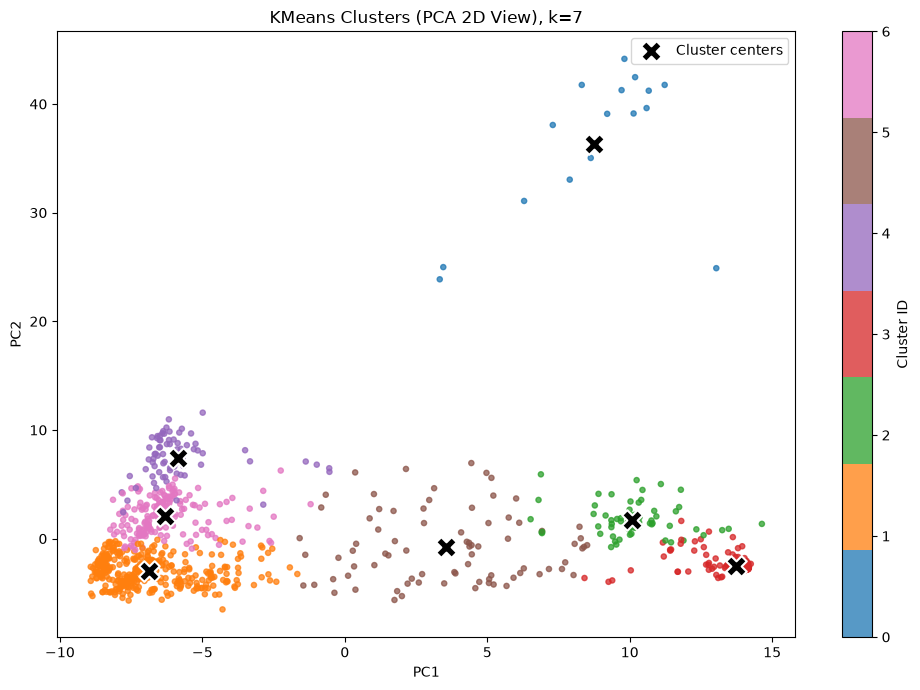

In [120]:
# snagged some code online for plotting KMeans clusters with PCA projection

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Use one consistent feature space for both KMeans and PCA projection
n_clusters = 7
X = StandardScaler().fit_transform(embeddings)

km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
labels = km.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(X)
centers_2d = pca.transform(km.cluster_centers_)

# Discrete colormap for cluster ids
base_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
cmap = ListedColormap(base_colors[:n_clusters])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap=cmap,
    s=14,
    alpha=0.75,
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c="black",
    s=220,
    marker="X",
    linewidths=1.5,
    edgecolors="white",
    label="Cluster centers",
)

plt.title(f"KMeans Clusters (PCA 2D View), k={n_clusters}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")

cbar = plt.colorbar(scatter, ticks=range(n_clusters))
cbar.set_label("Cluster ID")

plt.tight_layout()
plt.show()

Could look for significant features here (but i dont think i know enough about bluetooth to know whats a feature here....) so lets build a predictor

In [122]:
from collections import Counter

X_train = embeddings

# Use true class labels (targets), not cluster labels
Y_train = np.array([int(t) for t in targets], dtype=int)

scaler = StandardScaler()
Xs = scaler.fit_transform(X_train)

# Fit a fresh KMeans model used for prediction
n_clusters = len(np.unique(Y_train))
km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
cluster_ids = km.fit_predict(Xs)

# Map each cluster to the most common true class within that cluster
cluster_to_class = {}
for c in range(n_clusters):
    cls_in_cluster = Y_train[cluster_ids == c]
    cluster_to_class[c] = Counter(cls_in_cluster).most_common(1)[0][0]

def predict_class(new_embedding_1d):
    x = np.asarray(new_embedding_1d).reshape(1, -1)
    x = scaler.transform(x)
    c = int(km.predict(x)[0])
    return int(cluster_to_class[c]), c

try it once

In [123]:
randidx = random.randint(0, len(embeddings) - 1)

filenames = sorted([f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")])
filename = filenames[randidx]

target = int(filename.split('_')[2][6:])

new_embedding = embeddings[randidx]

pred_class, pred_cluster = predict_class(new_embedding)
print(f"Predicted class: {pred_class}, Predicted cluster: {pred_cluster}", f"Target: {target}")

filename = filenames[randidx]

Predicted class: 0, Predicted cluster: 1 Target: 4


In [124]:
def scoreall(embeddings, data_path):
    filenames = sorted([f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")])

    # Guard against mismatch between files and embedding count
    n = min(len(embeddings), len(filenames))

    correct = 0
    for randidx in range(n):
        filename = filenames[randidx]
        target = int(filename.split('_')[2][6:])
        new_embedding = embeddings[randidx]
        pred_class, pred_cluster = predict_class(new_embedding)
        if pred_class == target:
            correct += 1

    return correct / n if n > 0 else 0

results = scoreall(embeddings, data_path)
print(f"Accuracy: {results:.4f}")

Accuracy: 0.2897


In [125]:
# simple resnet training

# model = torchvision.models.resnet18(pretrained=True)

class CNNWithclassifier(nn.Module):
    def __init__(self, base_model, num_classes):
        self.base_model = base_model
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)
    

In [126]:
# simple 3 block cnn

class DirectEmbeddingCNN(nn.Module):
    def __init__(self, in_channels=2, num_classes=7, emb_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.embedding_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, emb_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        emb = self.embedding_head(x)
        logits = self.classifier(emb)
        return emb, logits


num_classes = len({int(f.split('_')[2][6:]) for f in os.listdir(data_path) if f.endswith('.pt') and f.startswith('IQdata')})
train_dataset = DroneRFDataSet(data_path, SpectrogramTransform(), samplesize=600)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = DirectEmbeddingCNN(in_channels=2, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for _, target, x in train_loader:
        x = x.to(device)
        y = torch.tensor([int(t) for t in target], device=device)

        optimizer.zero_grad()
        emb, logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        running_correct += (logits.argmax(1) == y).sum().item()
        running_total += x.size(0)

    print(f"epoch {epoch + 1}: loss={running_loss / running_total:.4f}, acc={running_correct / running_total:.4f}")


epoch 1: loss=1.9469, acc=0.1832
epoch 2: loss=1.9279, acc=0.2151
epoch 3: loss=1.9187, acc=0.2151
epoch 4: loss=1.9143, acc=0.1866
epoch 5: loss=1.9060, acc=0.2487


TODO:

could:

Use an ensemble of different batches/models?  (bootstrapping)
>
resample every epoch to keep eveything fresh?
>
use a more advanced model (Transformer?)